<a href="https://colab.research.google.com/github/jnahMoch/revisedBookRecommender/blob/main/semantic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm

booksDF = pd.read_csv("books_with_categories_and_genre.csv")
booksDF['description'] = booksDF['description'].fillna('')

In [4]:
emotion_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]
isbn = []
emotion_scores = {label: [] for label in emotion_labels}

In [5]:
print("Loading Deep Learning Emotion Transformer model...")
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)

Loading Deep Learning Emotion Transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [6]:
def calculate_max_emotion_score(predictions):
    per_emotion_scores = {label: [] for label in emotion_labels}
    for sentence_pred in predictions:
        for single_emotion in sentence_pred:
            lbl = single_emotion["label"]
            if lbl in per_emotion_scores:
                per_emotion_scores[lbl].append(single_emotion["score"])

    # Return max confidence score, fallback to 0.0 if empty
    return {label: (np.max(scores) if scores else 0.0) for label, scores in per_emotion_scores.items()}

In [7]:
print("Extracting emotion sentiment fields across books...")
for i in tqdm(range(len(booksDF))):
    isbn.append(booksDF["isbn13"][i])
    desc = booksDF["description"][i].strip()

    if not desc:
        for label in emotion_labels:
            emotion_scores[label].append(0.0)
        continue

    sentences = [s.strip() for s in desc.split(".") if s.strip()]
    if not sentences:
        sentences = [desc]

    predictions = classifier(sentences)
    max_scores = calculate_max_emotion_score(predictions)

    for label in emotion_labels:
        emotion_scores[label].append(max_scores[label])

Extracting emotion sentiment fields across books...


100%|██████████| 1042/1042 [05:55<00:00,  2.93it/s]


In [9]:
emotions_df = pd.DataFrame(emotion_scores)
emotions_df["isbn13"] = isbn

books_enriched = pd.merge(booksDF, emotions_df, on="isbn13")

books_enriched.to_csv("books_with_categories_genre_and_emotion.csv", index=False)

Cross-Category Emotion Verification
                               joy      fear     anger   sadness   neutral
simple_categories_binary                                                  
fiction                   0.322261  0.288982  0.155317  0.212924  0.601337
nonfiction                0.311997  0.201136  0.110274  0.127893  0.745155




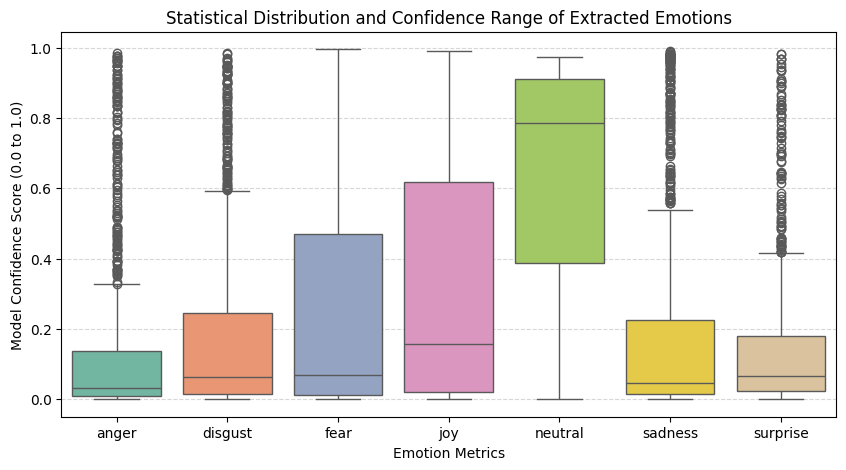

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Cross-Category Emotion Verification")
category_eval = books_enriched.groupby("simple_categories_binary")[["joy", "fear", "anger", "sadness", "neutral"]].mean()
print(category_eval)
print("\n" + "="*50 + "\n")

plt.figure(figsize=(10, 5))
sns.boxplot(data=books_enriched[emotion_labels], palette="Set2")
plt.title("Statistical Distribution and Confidence Range of Extracted Emotions")
plt.ylabel("Model Confidence Score (0.0 to 1.0)")
plt.xlabel("Emotion Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()